# Transformer Architecture: From Tokens to Contextual Representations

In the previous notebook, raw text was converted into token IDs and attention masks.

A Transformer takes these token IDs and learns contextual representations using embeddings, positional encoding, self-attention, feed-forward layers, residual connections, and layer normalization.

## Introduction

Transformers are the foundation of modern Large Language Models. They replaced many recurrent architectures by using self-attention, which allows every token to directly compare itself with every other token in the same sequence.

Unlike RNNs, Transformers process tokens in parallel. Instead of reading a sentence one step at a time, they build contextual token representations by repeatedly mixing information across the full sequence.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except ImportError:
    display = print

np.random.seed(42)

plt.style.use("default")
plt.rcParams.update({
    "figure.figsize": (10, 4),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 10,
})

## Transformer Architecture Overview

A Transformer block is a reusable module. Large models are usually built by stacking many of these blocks.

At a high level, the sequence flows through embeddings, positional information, self-attention, residual paths, normalization, and feed-forward transformations.

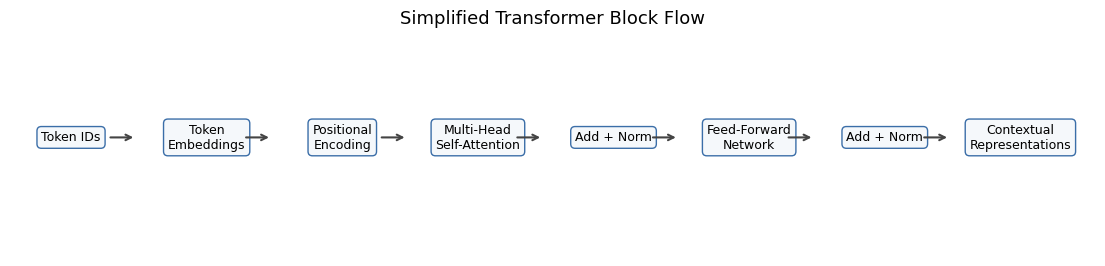

In [2]:
overview_steps = [
    "Token IDs",
    "Token\nEmbeddings",
    "Positional\nEncoding",
    "Multi-Head\nSelf-Attention",
    "Add + Norm",
    "Feed-Forward\nNetwork",
    "Add + Norm",
    "Contextual\nRepresentations",
]

fig, ax = plt.subplots(figsize=(14, 2.8))
ax.axis("off")
ax.set_xlim(0, len(overview_steps))
ax.set_ylim(0, 1)

for idx, label in enumerate(overview_steps):
    ax.text(
        idx + 0.45,
        0.55,
        label,
        ha="center",
        va="center",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.35", facecolor="#f5f8fb", edgecolor="#3b6ea8"),
    )
    if idx < len(overview_steps) - 1:
        ax.annotate(
            "",
            xy=(idx + 0.93, 0.55),
            xytext=(idx + 0.72, 0.55),
            arrowprops=dict(arrowstyle="->", lw=1.5, color="#444444"),
        )

ax.set_title("Simplified Transformer Block Flow", fontsize=13, pad=12)
plt.show()

## From Token IDs to Embeddings

Token IDs are integer indices into a vocabulary. The integer itself does not contain meaning. For example, token ID `8` is not naturally closer to token ID `9` than token ID `100`.

An embedding layer converts token IDs into dense vectors. These vectors are learned during training and become the model's first representation of each token.

In [3]:
tokens = ["the", "model", "learns", "context"]
token_to_id = {token: idx for idx, token in enumerate(tokens)}
token_ids = np.array([token_to_id[token] for token in tokens])

embedding_dim = 6
embedding_matrix = np.round(np.random.normal(0, 0.2, size=(len(tokens), embedding_dim)), 3)
token_embeddings = embedding_matrix[token_ids]

embedding_df = pd.DataFrame(token_embeddings, index=tokens, columns=[f"dim_{i}" for i in range(embedding_dim)])
embedding_df.insert(0, "token_id", token_ids)
display(embedding_df)

,token_id,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5
the,0,0.099,-0.028,0.130,0.305,-0.047,-0.047
model,1,0.316,0.153,-0.094,0.109,-0.093,-0.093
learns,2,0.048,-0.383,-0.345,-0.112,-0.203,0.063
context,3,-0.182,-0.282,0.293,-0.045,0.014,-0.285


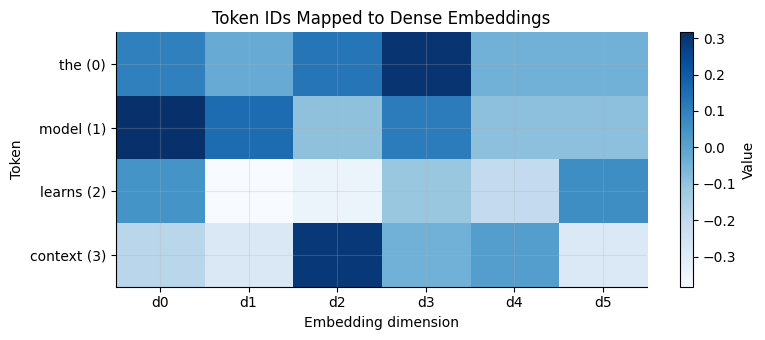

In [4]:
fig, ax = plt.subplots(figsize=(8, 3.5))
im = ax.imshow(token_embeddings, aspect="auto", cmap="Blues")
ax.set_title("Token IDs Mapped to Dense Embeddings")
ax.set_xlabel("Embedding dimension")
ax.set_ylabel("Token")
ax.set_xticks(range(embedding_dim))
ax.set_xticklabels([f"d{i}" for i in range(embedding_dim)])
ax.set_yticks(range(len(tokens)))
ax.set_yticklabels([f"{token} ({idx})" for token, idx in zip(tokens, token_ids)])
fig.colorbar(im, ax=ax, label="Value")
plt.tight_layout()
plt.show()

## Why Positional Information Is Needed

Self-attention compares tokens with each other, but it does not inherently know word order.

Consider these sentences:

- `Dog bites man`
- `Man bites dog`

They contain the same words, but the meaning changes because the positions changed. Transformers need positional information so the model can distinguish order-sensitive patterns.

In [5]:
order_examples = pd.DataFrame({
    "sentence": ["Dog bites man", "Man bites dog"],
    "same_tokens": ["dog, bites, man", "dog, bites, man"],
    "meaning": ["dog is the actor", "man is the actor"],
})

display(order_examples)

,sentence,same_tokens,meaning
0,Dog bites man,"dog, bites, man",dog is the actor
1,Man bites dog,"dog, bites, man",man is the actor


## Positional Encoding

There are two common ways to add position:

- learned positional embeddings: position vectors are learned like token embeddings
- sinusoidal positional encoding: position vectors are computed using sine and cosine waves

The original Transformer paper used sinusoidal positional encodings. The code below implements a compact NumPy version.

In [6]:
def sinusoidal_positional_encoding(sequence_length, model_dim):
    """Create sinusoidal positional encodings.

    Parameters
    ----------
    sequence_length : int
        Number of positions in the sequence.
    model_dim : int
        Embedding dimension. Should be even for the classic formulation.
    """
    positions = np.arange(sequence_length)[:, np.newaxis]
    dimensions = np.arange(model_dim)[np.newaxis, :]
    angle_rates = 1 / np.power(10000, (2 * (dimensions // 2)) / model_dim)
    angle_radians = positions * angle_rates

    encodings = np.zeros((sequence_length, model_dim))
    encodings[:, 0::2] = np.sin(angle_radians[:, 0::2])
    encodings[:, 1::2] = np.cos(angle_radians[:, 1::2])
    return encodings

position_encoding = sinusoidal_positional_encoding(sequence_length=16, model_dim=embedding_dim)
print("Positional encoding shape:", position_encoding.shape)

Positional encoding shape: (16, 6)


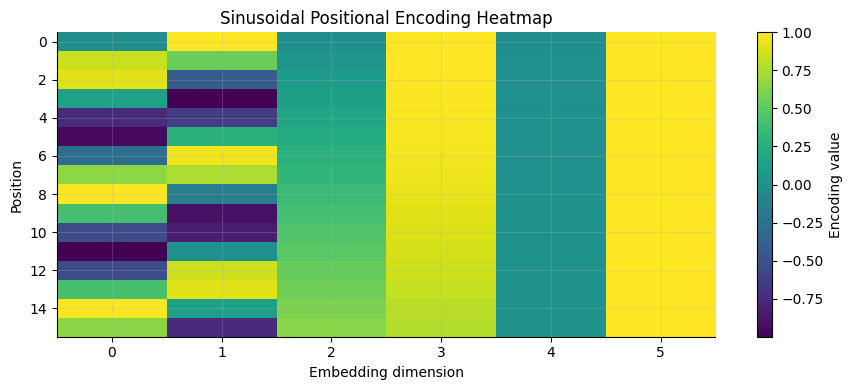

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(position_encoding, aspect="auto", cmap="viridis")
ax.set_title("Sinusoidal Positional Encoding Heatmap")
ax.set_xlabel("Embedding dimension")
ax.set_ylabel("Position")
ax.set_xticks(range(embedding_dim))
ax.set_yticks(range(0, 16, 2))
fig.colorbar(im, ax=ax, label="Encoding value")
plt.tight_layout()
plt.show()

In [8]:
sequence_position_encoding = position_encoding[:len(tokens)]
embeddings_with_position = token_embeddings + sequence_position_encoding

position_added_df = pd.DataFrame(
    np.round(embeddings_with_position, 3),
    index=tokens,
    columns=[f"dim_{i}" for i in range(embedding_dim)],
)
display(position_added_df)

,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5
the,0.099,0.972,0.130,1.305,-0.047,0.953
model,1.157,0.693,-0.048,1.108,-0.091,0.907
learns,0.957,-0.799,-0.252,0.884,-0.199,1.063
context,-0.041,-1.272,0.432,0.945,0.020,0.715


## Self-Attention Recap

Self-attention creates three views of each token representation:

- Query: what this token is looking for
- Key: what this token offers for comparison
- Value: what information this token can pass forward

Scaled dot-product attention computes scores between queries and keys, converts them into probabilities, and uses those probabilities to combine values.

In [9]:
def softmax(x, axis=-1):
    """Numerically stable softmax."""
    shifted = x - np.max(x, axis=axis, keepdims=True)
    exp_values = np.exp(shifted)
    return exp_values / np.sum(exp_values, axis=axis, keepdims=True)


def scaled_dot_product_attention(query, key, value, mask=None):
    """Compute scaled dot-product attention."""
    key_dim = query.shape[-1]
    scores = query @ key.T / np.sqrt(key_dim)

    if mask is not None:
        scores = np.where(mask == 0, -1e9, scores)

    attention_weights = softmax(scores, axis=-1)
    output = attention_weights @ value
    return output, attention_weights, scores

In [10]:
model_dim = embedding_dim
W_q = np.random.normal(0, 0.2, size=(model_dim, model_dim))
W_k = np.random.normal(0, 0.2, size=(model_dim, model_dim))
W_v = np.random.normal(0, 0.2, size=(model_dim, model_dim))

X = embeddings_with_position
Q = X @ W_q
K = X @ W_k
V = X @ W_v

attention_output, attention_weights, attention_scores = scaled_dot_product_attention(Q, K, V)

shape_table = pd.DataFrame({
    "matrix": ["X", "W_q", "Q", "K", "V", "attention_scores", "attention_weights", "attention_output"],
    "shape": [X.shape, W_q.shape, Q.shape, K.shape, V.shape, attention_scores.shape, attention_weights.shape, attention_output.shape],
})
display(shape_table)

,matrix,shape
0,X,"(4, 6)"
1,W_q,"(6, 6)"
2,Q,"(4, 6)"
3,K,"(4, 6)"
4,V,"(4, 6)"
5,attention_scores,"(4, 4)"
6,attention_weights,"(4, 4)"
7,attention_output,"(4, 6)"


In [11]:
attention_df = pd.DataFrame(
    np.round(attention_weights, 3),
    index=[f"query: {token}" for token in tokens],
    columns=[f"key: {token}" for token in tokens],
)
display(attention_df)

,key: the,key: model,key: learns,key: context
query: the,0.253,0.279,0.245,0.224
query: model,0.249,0.269,0.245,0.236
query: learns,0.250,0.266,0.244,0.240
query: context,0.245,0.267,0.250,0.238


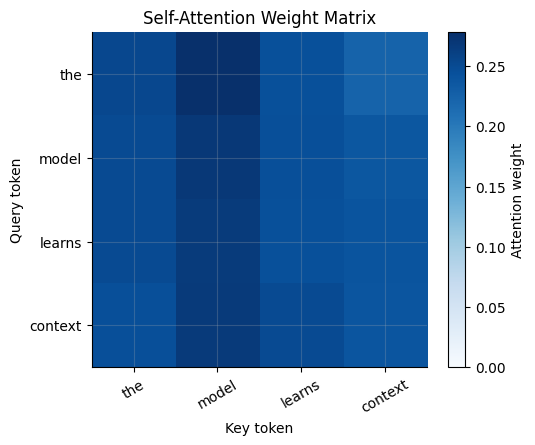

In [12]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(attention_weights, cmap="Blues", vmin=0, vmax=attention_weights.max())
ax.set_title("Self-Attention Weight Matrix")
ax.set_xlabel("Key token")
ax.set_ylabel("Query token")
ax.set_xticks(range(len(tokens)))
ax.set_yticks(range(len(tokens)))
ax.set_xticklabels(tokens, rotation=30)
ax.set_yticklabels(tokens)
fig.colorbar(im, ax=ax, label="Attention weight")
plt.tight_layout()
plt.show()

## Multi-Head Attention Intuition

A single attention head can learn one type of relationship. Multiple heads allow the model to focus on different relationships at the same time.

Different heads might learn subject-verb relationships, entity links, long-range dependencies, or local phrase patterns. Multi-head attention is not multiple separate models. It is one module with several attention projections.

In [13]:
def split_heads(x, num_heads):
    """Split a sequence representation into attention heads."""
    sequence_length, model_dim = x.shape
    if model_dim % num_heads != 0:
        raise ValueError("model_dim must be divisible by num_heads")
    head_dim = model_dim // num_heads
    return x.reshape(sequence_length, num_heads, head_dim).transpose(1, 0, 2)


def simplified_multi_head_attention(x, num_heads=2):
    """Educational multi-head self-attention using NumPy."""
    sequence_length, model_dim = x.shape
    head_dim = model_dim // num_heads

    projections = {}
    for name in ["q", "k", "v"]:
        projections[name] = np.random.normal(0, 0.2, size=(model_dim, model_dim))

    q_heads = split_heads(x @ projections["q"], num_heads)
    k_heads = split_heads(x @ projections["k"], num_heads)
    v_heads = split_heads(x @ projections["v"], num_heads)

    head_outputs = []
    head_weights = []
    for head_idx in range(num_heads):
        output, weights, _ = scaled_dot_product_attention(
            q_heads[head_idx],
            k_heads[head_idx],
            v_heads[head_idx],
        )
        head_outputs.append(output)
        head_weights.append(weights)

    concatenated = np.concatenate(head_outputs, axis=-1)
    output_projection = np.random.normal(0, 0.2, size=(model_dim, model_dim))
    projected_output = concatenated @ output_projection
    return projected_output, np.array(head_weights)

multi_head_output, multi_head_weights = simplified_multi_head_attention(X, num_heads=2)
print("Multi-head output shape:", multi_head_output.shape)
print("Attention weights shape:", multi_head_weights.shape)

Multi-head output shape: (4, 6)
Attention weights shape: (2, 4, 4)


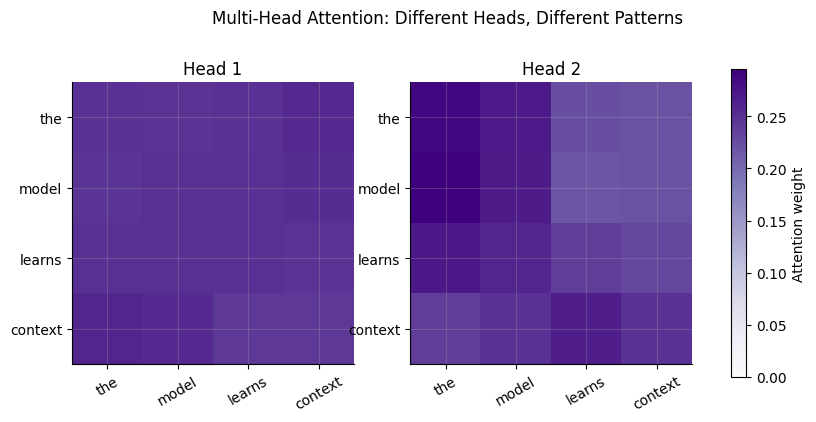

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for head_idx, ax in enumerate(axes):
    im = ax.imshow(multi_head_weights[head_idx], cmap="Purples", vmin=0, vmax=multi_head_weights.max())
    ax.set_title(f"Head {head_idx + 1}")
    ax.set_xticks(range(len(tokens)))
    ax.set_yticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=30)
    ax.set_yticklabels(tokens)
fig.suptitle("Multi-Head Attention: Different Heads, Different Patterns", y=1.03)
fig.colorbar(im, ax=axes, label="Attention weight")
plt.show()

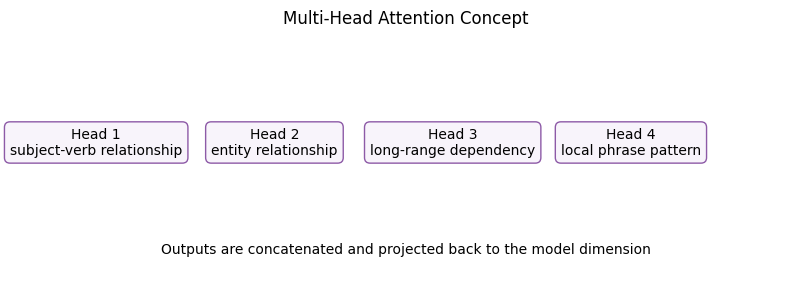

In [15]:
head_roles = [
    "subject-verb relationship",
    "entity relationship",
    "long-range dependency",
    "local phrase pattern",
]

fig, ax = plt.subplots(figsize=(10, 3.2))
ax.axis("off")
for idx, role in enumerate(head_roles):
    x = 0.1 + idx * 0.23
    ax.text(
        x,
        0.55,
        f"Head {idx + 1}\n{role}",
        ha="center",
        va="center",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#f8f4fb", edgecolor="#8d5aa7"),
    )
ax.text(0.5, 0.1, "Outputs are concatenated and projected back to the model dimension", ha="center")
ax.set_title("Multi-Head Attention Concept")
plt.show()

## Feed-Forward Network

After attention mixes information across tokens, each token representation passes through the same small neural network.

A Transformer feed-forward network is usually:

Linear layer → activation function → linear layer

This transforms each token independently after attention has already mixed sequence-level context.

In [16]:
def relu(x):
    """ReLU activation."""
    return np.maximum(0, x)


def feed_forward_network(x, hidden_dim=12):
    """Apply a small position-wise feed-forward network."""
    model_dim = x.shape[-1]
    W_1 = np.random.normal(0, 0.2, size=(model_dim, hidden_dim))
    b_1 = np.zeros(hidden_dim)
    W_2 = np.random.normal(0, 0.2, size=(hidden_dim, model_dim))
    b_2 = np.zeros(model_dim)
    hidden = relu(x @ W_1 + b_1)
    output = hidden @ W_2 + b_2
    return output, hidden

ffn_output, ffn_hidden = feed_forward_network(attention_output)
print("Attention output shape:", attention_output.shape)
print("FFN hidden shape:", ffn_hidden.shape)
print("FFN output shape:", ffn_output.shape)

Attention output shape: (4, 6)
FFN hidden shape: (4, 12)
FFN output shape: (4, 6)


## Residual Connections

Residual connections add a layer's input back to its output:

`output = layer_input + layer_output`

This helps gradients flow through deep networks and makes it easier to train many stacked Transformer blocks.

In [17]:
layer_input = np.array([0.8, -0.2, 0.4, 0.1])
layer_update = np.array([0.1, 0.3, -0.2, 0.2])
residual_output = layer_input + layer_update

residual_df = pd.DataFrame({
    "layer_input": layer_input,
    "layer_update": layer_update,
    "residual_output": residual_output,
})
display(residual_df)

,layer_input,layer_update,residual_output
0,0.8,0.1,0.9
1,-0.2,0.3,0.1
2,0.4,-0.2,0.2
3,0.1,0.2,0.3


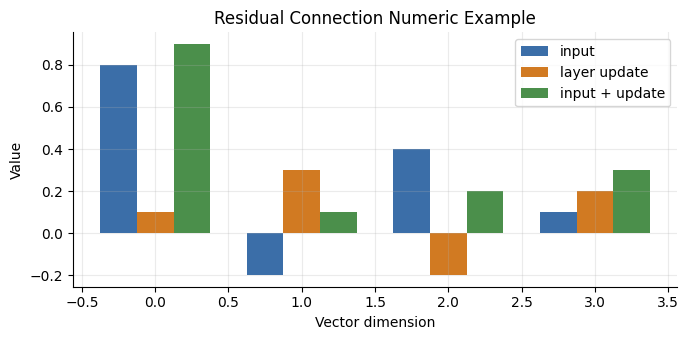

In [18]:
fig, ax = plt.subplots(figsize=(7, 3.5))
indices = np.arange(len(layer_input))
ax.bar(indices - 0.25, layer_input, width=0.25, label="input", color="#3b6ea8")
ax.bar(indices, layer_update, width=0.25, label="layer update", color="#d17a22")
ax.bar(indices + 0.25, residual_output, width=0.25, label="input + update", color="#4b8f4b")
ax.set_title("Residual Connection Numeric Example")
ax.set_xlabel("Vector dimension")
ax.set_ylabel("Value")
ax.legend()
plt.tight_layout()
plt.show()

## Layer Normalization

Layer normalization stabilizes representations by normalizing values across the feature dimension for each token.

This keeps activations in a more consistent range, which is especially useful when stacking many Transformer blocks.

In [19]:
def layer_norm(x, epsilon=1e-6):
    """Apply layer normalization across the last dimension."""
    mean = np.mean(x, axis=-1, keepdims=True)
    variance = np.var(x, axis=-1, keepdims=True)
    return (x - mean) / np.sqrt(variance + epsilon)

sample_representations = np.array([
    [2.0, 4.0, 6.0, 8.0],
    [0.5, -1.0, 3.0, 2.0],
])
normalized_representations = layer_norm(sample_representations)

stats_df = pd.DataFrame({
    "row": ["before_0", "before_1", "after_0", "after_1"],
    "mean": [
        sample_representations[0].mean(),
        sample_representations[1].mean(),
        normalized_representations[0].mean(),
        normalized_representations[1].mean(),
    ],
    "std": [
        sample_representations[0].std(),
        sample_representations[1].std(),
        normalized_representations[0].std(),
        normalized_representations[1].std(),
    ],
})
display(stats_df)

,row,mean,std
0,before_0,5.000000e+00,2.236068
1,before_1,1.125000e+00,1.515544
2,after_0,0.000000e+00,1.000000
3,after_1,-5.551115e-17,1.000000


## Transformer Encoder Block

A simplified encoder block combines the pieces:

Input embeddings + positional encoding → multi-head self-attention → residual connection → layer normalization → feed-forward network → residual connection → layer normalization

Real models add details such as dropout, learned parameters, bias terms, and optimized tensor operations. The educational version below keeps the structure visible.

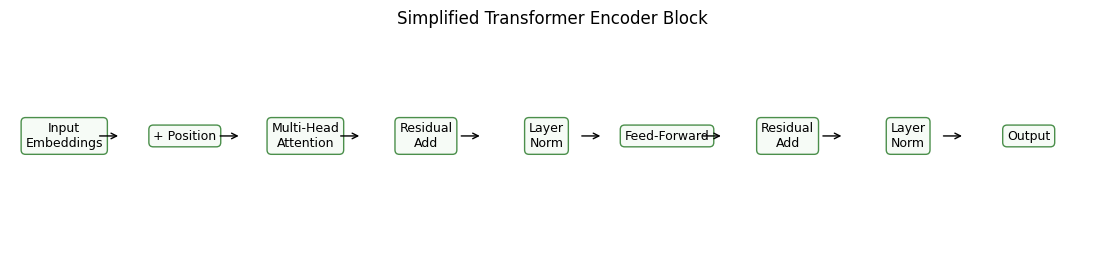

In [20]:
block_steps = [
    "Input\nEmbeddings",
    "+ Position",
    "Multi-Head\nAttention",
    "Residual\nAdd",
    "Layer\nNorm",
    "Feed-Forward",
    "Residual\nAdd",
    "Layer\nNorm",
    "Output",
]

fig, ax = plt.subplots(figsize=(14, 3))
ax.axis("off")
ax.set_xlim(0, len(block_steps))
ax.set_ylim(0, 1)

for idx, step in enumerate(block_steps):
    ax.text(
        idx + 0.45,
        0.55,
        step,
        ha="center",
        va="center",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.35", facecolor="#f6fbf6", edgecolor="#4b8f4b"),
    )
    if idx < len(block_steps) - 1:
        ax.annotate("", xy=(idx + 0.92, 0.55), xytext=(idx + 0.72, 0.55), arrowprops=dict(arrowstyle="->"))

ax.set_title("Simplified Transformer Encoder Block")
plt.show()

In [21]:
def transformer_encoder_block(x, num_heads=2, hidden_dim=12):
    """Run a simplified Transformer encoder block."""
    attention_result, attention_maps = simplified_multi_head_attention(x, num_heads=num_heads)
    after_attention = layer_norm(x + attention_result)

    ffn_result, _ = feed_forward_network(after_attention, hidden_dim=hidden_dim)
    block_output = layer_norm(after_attention + ffn_result)
    return block_output, attention_maps

encoder_output, encoder_attention_maps = transformer_encoder_block(X, num_heads=2, hidden_dim=12)
print("Input shape:", X.shape)
print("Encoder output shape:", encoder_output.shape)
print("Attention map shape:", encoder_attention_maps.shape)

Input shape: (4, 6)
Encoder output shape: (4, 6)
Attention map shape: (2, 4, 4)


## Encoder vs Decoder

Transformer architecture appears in three common configurations:

- Encoder-only models read an input sequence and build contextual representations.
- Decoder-only models generate tokens autoregressively.
- Encoder-decoder models read one sequence and generate another sequence.

In [22]:
comparison_df = pd.DataFrame({
    "architecture": ["Encoder-only", "Decoder-only", "Encoder-Decoder"],
    "main behavior": ["reads and represents input", "generates next tokens", "maps input sequence to output sequence"],
    "masking": ["usually bidirectional attention", "causal masking", "encoder attention + causal decoder attention"],
    "example models": ["BERT", "GPT", "T5"],
})

display(comparison_df)

,architecture,main behavior,masking,example models
0,Encoder-only,reads and represents input,usually bidirectional attention,BERT
1,Decoder-only,generates next tokens,causal masking,GPT
2,Encoder-Decoder,maps input sequence to output sequence,encoder attention + causal decoder attention,T5


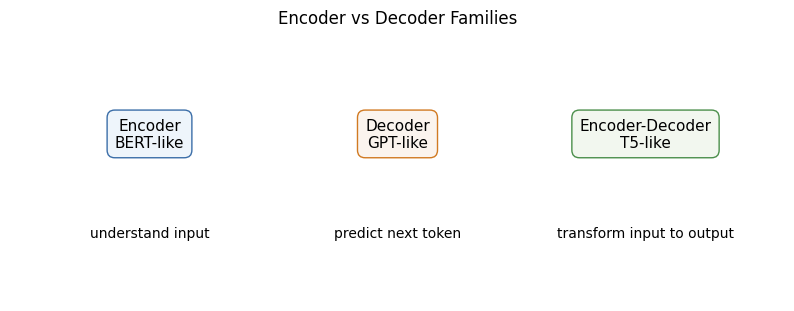

In [23]:
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.axis("off")
columns = [0.18, 0.5, 0.82]
labels = ["Encoder\nBERT-like", "Decoder\nGPT-like", "Encoder-Decoder\nT5-like"]
details = ["understand input", "predict next token", "transform input to output"]
colors = ["#eef5fb", "#fbf4ee", "#f2f7ef"]
edges = ["#3b6ea8", "#d17a22", "#4b8f4b"]

for x_pos, label, detail, color, edge in zip(columns, labels, details, colors, edges):
    ax.text(x_pos, 0.62, label, ha="center", va="center", bbox=dict(boxstyle="round,pad=0.5", facecolor=color, edgecolor=edge), fontsize=11)
    ax.text(x_pos, 0.25, detail, ha="center", va="center", fontsize=10)

ax.set_title("Encoder vs Decoder Families")
plt.show()

## Causal Masking

Decoder-only models such as GPT generate text from left to right. During training, the model should not look at future tokens when predicting the next token.

A causal mask prevents each position from attending to positions on its right.

In [24]:
def causal_mask(sequence_length):
    """Create a lower-triangular causal attention mask."""
    return np.tril(np.ones((sequence_length, sequence_length), dtype=int))

mask = causal_mask(sequence_length=8)
display(pd.DataFrame(mask, columns=[f"key_{i}" for i in range(8)], index=[f"query_{i}" for i in range(8)]))

,key_0,key_1,key_2,key_3,key_4,key_5,key_6,key_7
query_0,1,0,0,0,0,0,0,0
query_1,1,1,0,0,0,0,0,0
query_2,1,1,1,0,0,0,0,0
query_3,1,1,1,1,0,0,0,0
query_4,1,1,1,1,1,0,0,0
query_5,1,1,1,1,1,1,0,0
query_6,1,1,1,1,1,1,1,0
query_7,1,1,1,1,1,1,1,1


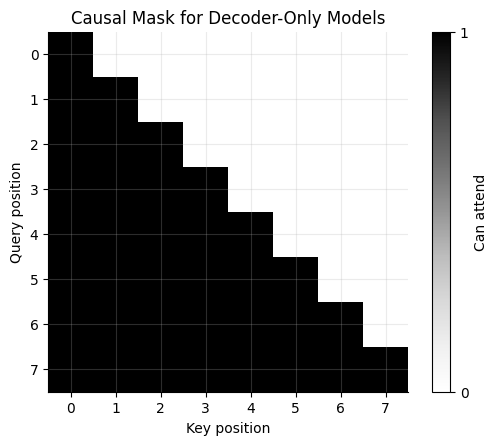

In [25]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(mask, cmap="Greys", vmin=0, vmax=1)
ax.set_title("Causal Mask for Decoder-Only Models")
ax.set_xlabel("Key position")
ax.set_ylabel("Query position")
ax.set_xticks(range(8))
ax.set_yticks(range(8))
fig.colorbar(im, ax=ax, ticks=[0, 1], label="Can attend")
plt.tight_layout()
plt.show()

## Mini Project: Tiny Transformer Block Visualizer

This mini project follows a short sentence through a simplified Transformer-style flow:

1. tokenize using whitespace
2. create token IDs
3. create embeddings
4. add positional encoding
5. apply simplified self-attention
6. show the attention matrix
7. show contextualized output vectors

In [26]:
def whitespace_tokenize(text):
    """Simple whitespace tokenizer for educational examples."""
    return text.lower().split()


def build_token_ids(token_list):
    """Build a vocabulary and convert tokens to IDs."""
    vocabulary = {token: idx for idx, token in enumerate(dict.fromkeys(token_list))}
    ids = np.array([vocabulary[token] for token in token_list])
    return vocabulary, ids


def tiny_transformer_visualizer(sentence, model_dim=8):
    """Run a short sentence through a tiny Transformer-style pipeline."""
    token_list = whitespace_tokenize(sentence)
    vocabulary, ids = build_token_ids(token_list)

    embedding_table = np.random.normal(0, 0.2, size=(len(vocabulary), model_dim))
    embeddings = embedding_table[ids]
    positions = sinusoidal_positional_encoding(len(token_list), model_dim)
    x = embeddings + positions

    W_q = np.random.normal(0, 0.2, size=(model_dim, model_dim))
    W_k = np.random.normal(0, 0.2, size=(model_dim, model_dim))
    W_v = np.random.normal(0, 0.2, size=(model_dim, model_dim))

    q = x @ W_q
    k = x @ W_k
    v = x @ W_v
    contextualized, attention, scores = scaled_dot_product_attention(q, k, v)

    return {
        "tokens": token_list,
        "token_ids": ids,
        "vocabulary": vocabulary,
        "embedding_shape": embeddings.shape,
        "attention": attention,
        "attention_scores": scores,
        "contextualized_output": contextualized,
        "output_shape": contextualized.shape,
    }

mini_result = tiny_transformer_visualizer("the model learns context from tokens")
print("Tokens:", mini_result["tokens"])
print("Token IDs:", mini_result["token_ids"].tolist())
print("Embedding shape:", mini_result["embedding_shape"])
print("Output representation shape:", mini_result["output_shape"])

Tokens: ['the', 'model', 'learns', 'context', 'from', 'tokens']
Token IDs: [0, 1, 2, 3, 4, 5]
Embedding shape: (6, 8)
Output representation shape: (6, 8)


In [27]:
mini_table = pd.DataFrame({
    "token": mini_result["tokens"],
    "token_id": mini_result["token_ids"],
})
display(mini_table)

,token,token_id
0,the,0
1,model,1
2,learns,2
3,context,3
4,from,4
5,tokens,5


In [28]:
mini_attention_df = pd.DataFrame(
    np.round(mini_result["attention"], 3),
    index=[f"query: {token}" for token in mini_result["tokens"]],
    columns=[f"key: {token}" for token in mini_result["tokens"]],
)
display(mini_attention_df)

,key: the,key: model,key: learns,key: context,key: from,key: tokens
query: the,0.131,0.163,0.189,0.203,0.161,0.153
query: model,0.142,0.170,0.191,0.191,0.156,0.150
query: learns,0.155,0.176,0.182,0.176,0.155,0.156
query: context,0.159,0.173,0.170,0.172,0.161,0.165
query: from,0.157,0.161,0.159,0.175,0.171,0.176
query: tokens,0.141,0.166,0.179,0.192,0.166,0.157


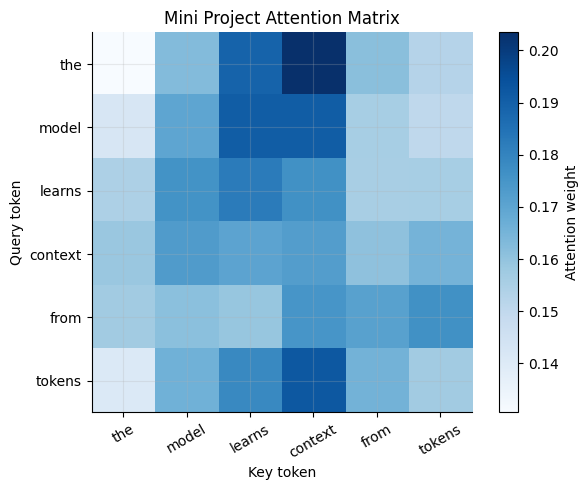

In [29]:
fig, ax = plt.subplots(figsize=(6.5, 5))
im = ax.imshow(mini_result["attention"], cmap="Blues")
ax.set_title("Mini Project Attention Matrix")
ax.set_xlabel("Key token")
ax.set_ylabel("Query token")
ax.set_xticks(range(len(mini_result["tokens"])))
ax.set_yticks(range(len(mini_result["tokens"])))
ax.set_xticklabels(mini_result["tokens"], rotation=30)
ax.set_yticklabels(mini_result["tokens"])
fig.colorbar(im, ax=ax, label="Attention weight")
plt.tight_layout()
plt.show()

In [30]:
contextualized_df = pd.DataFrame(
    np.round(mini_result["contextualized_output"], 3),
    index=mini_result["tokens"],
    columns=[f"dim_{i}" for i in range(mini_result["contextualized_output"].shape[1])],
)
display(contextualized_df)

,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7
the,0.029,0.214,-0.089,0.125,0.773,0.035,-0.593,0.334
model,0.039,0.231,-0.076,0.128,0.772,0.038,-0.579,0.327
learns,0.045,0.239,-0.066,0.133,0.771,0.033,-0.572,0.317
context,0.042,0.228,-0.067,0.137,0.770,0.023,-0.577,0.312
from,0.032,0.203,-0.076,0.139,0.769,0.010,-0.591,0.313
tokens,0.032,0.215,-0.083,0.129,0.771,0.029,-0.589,0.326


## Common Misunderstandings

- A Transformer is not only attention. Feed-forward layers, residual connections, normalization, embeddings, and positional information all matter.
- Positional encoding is necessary because self-attention alone is not order-aware.
- Multi-head attention is not multiple models. It is one attention module with multiple learned projections.
- Decoder models use masks so they cannot see future tokens during next-token prediction.
- Tokenization and architecture are separate steps. Tokenizers create IDs; Transformer blocks process those IDs.
- Larger models are usually stacks of repeated Transformer blocks.

## Why Transformers Scale Well

Transformers scale well because they process tokens in parallel, model long-range dependencies through attention, and use a modular architecture that can be stacked deeply. Their matrix-heavy computation also maps well to GPUs and other accelerators.

The main limitation is that full attention cost grows with sequence length. For a sequence of length `n`, the attention matrix has `n × n` pairwise comparisons.

## Real-World Models Built on Transformers

- BERT: encoder-only, often used for understanding tasks such as classification and retrieval.
- GPT: decoder-only, used for autoregressive generation and chat-style language modeling.
- T5: encoder-decoder, designed for sequence-to-sequence tasks such as summarization and translation.

These model families use different Transformer configurations, but they all rely on the same core ideas introduced in this notebook.

## Final Summary

Key takeaways:

- token IDs become embeddings
- positional encodings add order
- self-attention mixes information across tokens
- feed-forward layers transform token representations
- residual connections and layer normalization stabilize training
- causal masks allow autoregressive generation
- Transformer blocks are the foundation of LLMs

## Next Notebook

➡️ Next: Small Language Model

The next notebook will build a small language model to demonstrate next-token prediction and autoregressive text generation.